# Run all to produce all the plots for the 1D Free fermions

In [36]:
from freeFermions import *
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,            # Enable LaTeX rendering
    "font.family": "serif",         # Use a serif font
    "font.serif": ["Computer Modern"],  # Specify LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}" ,  # Optional: Load additional LaTeX packages
    'font.size': 18
})


#### Colors used in the plot
In order to uniformise the color scheme, I will fix a few colors early and use only those in all plots.

In [37]:
cmap = plt.cm.coolwarm
blue = cmap(0)
light_blue = cmap(0.25)
red = cmap(0.99)


# Photon distribution function - Fig. 2

/var/folders/kg/bcmlw4kd6cn745pz2tjkr7hw0000gp/T/ipykernel_82123/1021400400.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


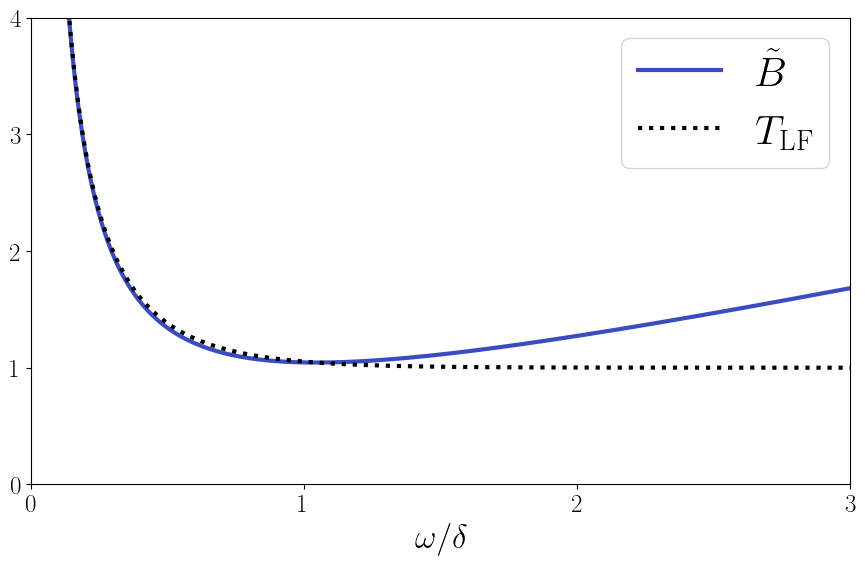

In [38]:
def plotBosonicDistribution():
    omegaMax = 3
    delta = 1
    Gamma = 3/5

    N_omega = 500
    omegas = np.linspace(0, omegaMax, num = N_omega+1)[1:]
    vals = bareBosonDistribution(omegas, delta , Gamma)

    T_LF = (1/(4*delta))*(delta**2 + (Gamma**2 / 4))
    thermal_distribution =( np.tanh( omegas/ (2*T_LF) ))**(-1)

    fig,ax = plt.subplots(figsize = (9,6))
    # ax.plot(omegas, vals, color = 'blue', label = r'$\tilde{B}$', linewidth = 2)
    ax.plot(omegas, vals, color = blue, label = r'$\tilde{B}$', linewidth = 3)
    ax.plot(omegas, thermal_distribution, color = 'black', label = r'$T_{\rm LF}$', linestyle = ':', linewidth = 3)
    # thermal_distribution =( np.tanh( omegas/ (4*T_LF) ))**(-1)
    # ax.plot(omegas, thermal_distribution, color = 'red', label = r'$2T_{\rm LF}$', linestyle = ':', linewidth = 1)

    ax.set_xlim(0,omegaMax)
    ax.set_ylim(0,4)
    ax.set_xticks([0,1,2,3])
    ax.set_xticklabels(['0', '1', '2', '3'])
    ax.set_yticks([0,1,2,3, 4])
    ax.set_yticklabels(['0', '1', '2', '3', '4'])
    ax.set_xlabel(r'$\omega/ \delta$', fontsize = 24)
    ax.legend(fontsize = 30)
    fig.tight_layout()
    # fig.savefig('bosonDistributionFunction.png', transparent=True, dpi = 400)
    fig.savefig('bosonDistributionFunction.pdf', transparent=True, dpi = 400)
    fig.show()

plotBosonicDistribution()


# Fermionic distribution - Fig. 4

## Fermionic distribution with temperature gradient - Fig. 4a

/var/folders/kg/bcmlw4kd6cn745pz2tjkr7hw0000gp/T/ipykernel_82123/727809406.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


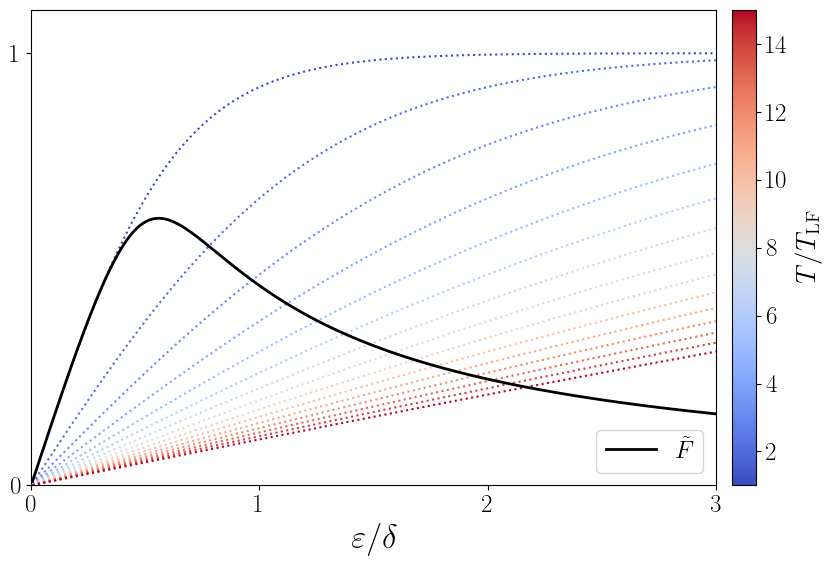

In [39]:
import matplotlib.colors as mcolors

omegaMax = 3
delta = 1
Gamma = delta
N_omega = 500

omegas = np.linspace(0, omegaMax, num = N_omega+1)[1:]
T_LF = (1/(4*delta))*(delta**2 + (Gamma**2 / 4))

B = bareBosonDistribution(2*omegas, delta , Gamma)
vals_new = B - np.sqrt(B**2 - 1)

# Thermal distributions from T_LF to T_max
n_temps = 15
T_max = 15 * T_LF
temperatures = np.linspace(T_LF, T_max, n_temps)
norm = mcolors.Normalize(vmin = 1, vmax = T_max / T_LF)

fig, ax = plt.subplots(figsize = (9,6))

# Plot thermal distributions (light blue to light red, dotted)
for T in temperatures:
    thermal = np.tanh(omegas / (2 * T))
    ax.plot(omegas, thermal, color = cmap(norm(T / T_LF)), linestyle = ':', linewidth = 1.5)

# Non-equilibrium distribution on top (solid black)
ax.plot(omegas, vals_new, color = 'black', label = r'$\tilde{F}$', linewidth = 2)


# Colorbar for temperature
sm = plt.cm.ScalarMappable(cmap = cmap, norm = norm)
cbar = fig.colorbar(sm, ax = ax, pad = 0.02)
cbar.set_label(r'$T / T_{\rm LF}$', fontsize = 20)
ax.set_xlim(0, omegaMax)
ax.set_ylim(0, 1.1)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['0', '1', '2', '3'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['0', '1'])
ax.set_xlabel(r'$\varepsilon/ \delta$', fontsize = 24)

ax.legend(loc = 'lower right')
fig.tight_layout()
# fig.savefig('FermionsDistribution.png', dpi = 400, transparent = True)
fig.savefig('FermionsDistribution.pdf', dpi = 400, transparent = True)
fig.show()

## Superimposing the DoS - Fig. 4b-d

### Computing the DoS

In [40]:
def localDoS(epsilons : np.array, g, phi, J, Q = 5, N_k = 10000):
    k_s = np.linspace(0, np.pi, num = N_k + 1, endpoint = False)[1: ]
    energies =  np.sqrt( 2*(J**2)*(1 + np.cos(k_s)) + (g*phi)**2  )
    # energies = energies_meanField(k_s, J, g, 0, phi)
    G_s = ( (1+  1j* (1/Q)  )* epsilons[:, np.newaxis] - energies[np.newaxis, :] )**(-1)
    Gloc = np.sum(G_s, axis=1)
    return - (1/2*np.pi)*np.imag(Gloc)

def omegasDoS(N_omegas, g, phi, J):
    omega_min = 0.9*np.abs(g*phi)
    omega_max = 1.2*np.sqrt(4* (J**2) + ((g*phi)**2) )
    return np.linspace(omega_min, omega_max, num=N_omegas)
    

### Doing the plots

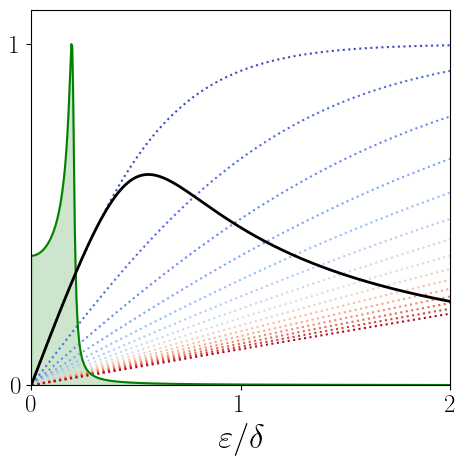

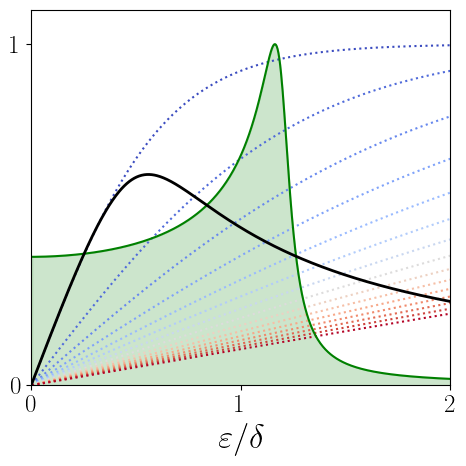

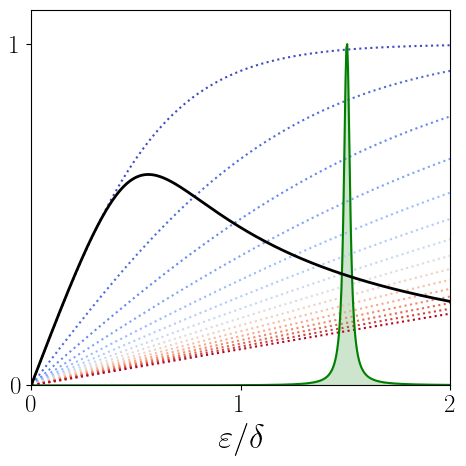

In [41]:
import matplotlib.colors as mcolors

omegaMax = 2
delta = 1
Gamma = delta
g = 0
phi = 1
J = 0.1
N_omega = 500

def plot_distribution_and_DoS(omegaMax,delta, Gamma, g, phi, J , N_omega, Q = 20, fileName = 'distributionAndDos.pdf' ):

    omegas = np.linspace(0, omegaMax, num = N_omega+1)[1:]
    T_LF = (1/(4*delta))*(delta**2 + (Gamma**2 / 4))

    B = bareBosonDistribution(2*omegas, delta , Gamma)
    vals_new = B - np.sqrt(B**2 - 1)

    # Thermal distributions from T_LF to T_max
    n_temps = 15
    T_max = 15 * T_LF
    temperatures = np.linspace(T_LF, T_max, n_temps)
    cmap = plt.cm.coolwarm
    norm = mcolors.Normalize(vmin = 1, vmax = T_max / T_LF)

    fig, ax = plt.subplots(figsize = (5,5))

    # Plot thermal distributions (light blue to light red, dotted)
    for T in temperatures:
        thermal = np.tanh(omegas / (2 * T))
        ax.plot(omegas, thermal, color = cmap(norm(T / T_LF)), linestyle = ':', linewidth = 1.5)

    DoS = True 
    if DoS :
        # omega_dos = omegasDoS(N_omega, g, phi, J )
        dos_val = localDoS(omegas, g, phi, J, Q = Q)
        dos_val = 2*dos_val/(2* np.max(dos_val))
        ax.fill_between(omegas, dos_val, alpha = 0.2, color = 'green')
        ax.plot(omegas, dos_val, color = 'green', linewidth = 1.5)

    # Non-equilibrium distribution on top (solid black)
    ax.plot(omegas, vals_new, color = 'black', label = r'$\tilde{F}$', linewidth = 2)

    ax.set_xlim(0, omegaMax)
    ax.set_ylim(0, 1.1)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['0', '1', '2'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['0', '1'])
    ax.set_xlabel(r'$\varepsilon/ \delta$', fontsize = 24)

    fig.tight_layout()
    fig.savefig(fileName, dpi = 400, transparent = True)
    # fig.show()


plot_distribution_and_DoS(omegaMax,delta, Gamma, 0, 0, 0.1 , N_omega, Q = 20, fileName = 'distributionAndDos_lowBandwith.pdf' )
plot_distribution_and_DoS(omegaMax,delta, Gamma, 0, 0, 0.6 , N_omega, Q = 20, fileName = 'distributionAndDos_highBandwith.pdf' )
plot_distribution_and_DoS(omegaMax,delta, Gamma, 1, 1.5, 0.1 , N_omega, Q = 100,  fileName = 'distributionAndDos_superradiantPhase.pdf' )

## Heat-Flux and effective temperature - Fig.4e
Here, we reproduce the procedure of Tolle et al. to define a temperature in the system by setting the heat-flux to zero. Once again we then compare the fluctuations of the order-parameter in the thermal and non-thermal ensembles. 


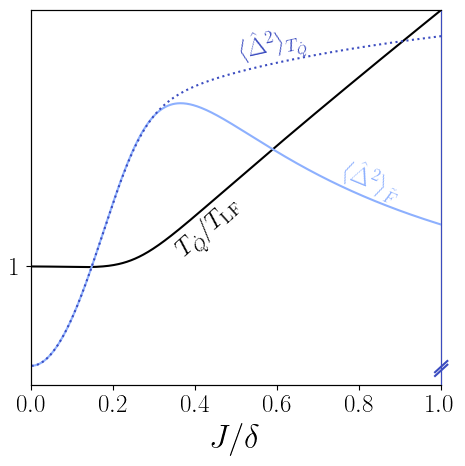

In [42]:
def heatFlux_thermalDistribution(T, J, Gamma, delta, g, phi, N_k =100):
    ks = np.linspace(0, np.pi, num=N_k+1, endpoint = False)[1:]
    energies = energies_meanField(ks, J, g, 0 , phi)
    F = np.tanh( energies /(2*T)  ) # F[:,0] is F_k,+ and F[:,1] is F_k,-
    DeltaEpsilon = energies[:, 0] - energies[:, 1]
    ukz = u_kz(ks, J, g, phi)
    ImTildeDr = np.imag(retarded_D(DeltaEpsilon, delta, Gamma))
    tildeB = bareBosonDistribution(DeltaEpsilon, delta, Gamma)

    tmp = (1 - (ukz**2)) * DeltaEpsilon * ImTildeDr * ( F[:,0] * F[:,1] - 1 + tildeB*(F[:,0] - F[:,1])  )
    return np.sum(tmp)/N_k

from scipy.optimize import root_scalar

def effectiveTemperatureSweep_heatFlux(Jmin, Jmax, delta, Gamma, g, phi, N_J):
    J_mem = np.linspace(Jmin, Jmax, num = N_J)
    T_eff = np.zeros_like(J_mem)
    
    T_LF = (1/(4*delta))*(delta**2 + (Gamma**2 / 4))

    for i in range(0, N_J):
        T_init = max(T_LF*1.01, T_eff[i-1])
        # E = energy_F(0, 0, J_mem[i], delta, Gamma)
        # print(E)
        def f(T):
            return heatFlux_thermalDistribution(T, J_mem[i], Gamma, delta, g, phi, N_k =100)
        sol = root_scalar(f, x0 = T_init)
        T_eff[i] = sol.root
        # print(sol.converged)
    # print(T_eff/T_LF) 
    return J_mem, T_eff/T_LF

def effectiveTemperature(J, Gamma, delta, g, phi, N_k, T_init = None):
        if T_init == None : 
            T_init = 1.01 * (1/(4*delta))*(delta**2 + (Gamma**2 / 4))
        def f(T):
            return heatFlux_thermalDistribution(T, J, Gamma, delta, g, phi, N_k = N_k)
        sol = root_scalar(f, x0 = T_init)
        T_eff = sol.root
        return T_eff



def fluctuation_F( J, delta, Gamma, N_k = 1000):
    k_s = np.linspace(0, np.pi, num = N_k + 1, endpoint = False)[1: ]
    energies = J*np.sqrt( 2*(1 + np.cos(k_s)) )
    occupations = bareFermionOccupation(energies, delta, Gamma) 
    tmp = 0.5 *( 1 +  occupations**2)
    return (1/N_k)*np.sum(tmp)

def fluctuation_T( J, T, N_k = 1000):
    k_s = np.linspace(0, np.pi, num = N_k + 1, endpoint = False)[1: ]
    energies = J*np.sqrt( 2*(1 + np.cos(k_s)) )
    occupations = np.tanh(energies / ( 2*T))
    tmp = 0.5 *( 1 +  occupations**2)
    return (1/N_k)*np.sum(tmp)
 


Jmin, Jmax, delta, Gamma, N_J = 0.001, 1, 1, 1, 500
g, phi = 0, 0 # normal phase
J, T  = effectiveTemperatureSweep_heatFlux(Jmin, Jmax, delta, Gamma, g, phi, N_J)

fig, ax = plt.subplots(figsize = (5,5))
ax.set_xlim(0, Jmax)
ax.set_ylim(0, np.max(T))
ax.set_yticks([ 1])
ax.set_yticklabels(['1']) #r'$T_{\rm LF}$'
ax.set_xlabel(r'$J/ \delta$', fontsize = 24)
ax.plot(J,T, color = 'black')


T_LF = (1/(4*delta))*(delta**2 + (Gamma**2 / 4))
DeltaFluctuations = np.zeros((N_J, 2)) #  fluctuations for (F, T)
for i in range(N_J):
    DeltaFluctuations[i, 0] = fluctuation_F(J[i], delta, Gamma)
    DeltaFluctuations[i, 1] = fluctuation_T(J[i],T_LF* T[i])


ax2 = ax.twinx()  # Instantiate a second axes that shares the same x-axis
color_right_axis =  blue  # Match the axis spine/text to the primary right-side curve 
ax2.plot(J, DeltaFluctuations[:, 0], c = light_blue ) 
ax2.plot(J, DeltaFluctuations[:, 1], c = blue , ls = ':') 
ax2.set_ylim(0.98*np.min(DeltaFluctuations), 1.02*np.max(DeltaFluctuations))
ax2.set_yticks([])
d = 0.015  

# Bottom-right cut marks (near the non-zero start)
kwargs = dict(transform=ax2.transAxes, color=color_right_axis, clip_on=False, lw=1.5)
shift = 0.05
ax2.plot([1 - d, 1 + d], [-d + shift, +d+ shift], **kwargs)
ax2.plot([1 - d, 1 + d], [-d - 0.01+ shift, +d - 0.01+ shift], **kwargs)

ax2.spines['right'].set_color(color_right_axis)

if True :
    ax.annotate(r'$T_{\dot{Q}}/T_{\rm LF}$', (0.75/2.2, 2.4/2.2), rotation = 42, color = 'black') # T_{\rm eff, Q}
    ax.annotate(r'$\langle \hat{\Delta}^2\rangle_{T_{\dot{Q} }}$', (0.5, 2.75), rotation = 12.5, color = blue) 
    ax.annotate(r'$\langle \hat{\Delta}^2\rangle_{\tilde{F}} $', (0.75, 1.57), rotation = -22.5, color = light_blue) 


fig.tight_layout()
fig.savefig('effectiveTemperaturNormalPhase.pdf', dpi = 400, transparent = True)

# Mean-field results - Fig. 5

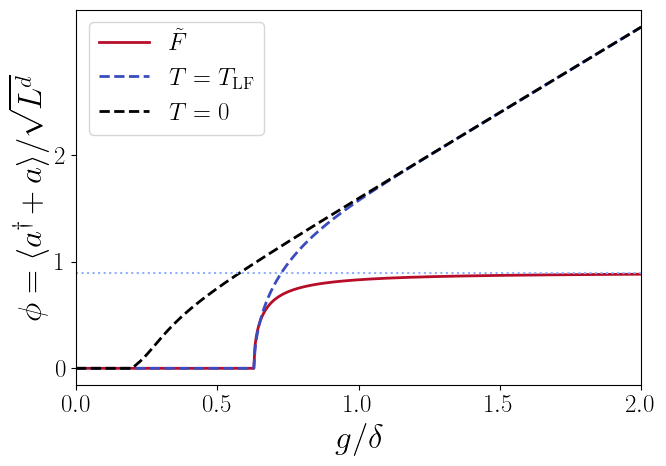

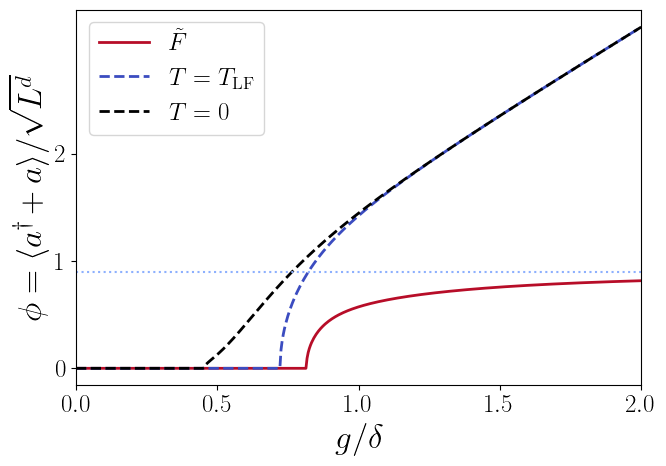

In [43]:
def plot_MF(J, delta, Gamma, gmax, n_gsteps = 500, N_int = 200, bar_n = 1, fileName = 'mf.pdf'):
    gs = np.linspace(0, gmax, n_gsteps)
    mu_mem = np.zeros((3, n_gsteps)) # 0 = cavity, 1 = LFET, 2 = zero temp
    phi_mem = np.zeros((3, n_gsteps))
    T_LF = (1/(4*delta))*(delta**2 + (Gamma**2 / 4))

    for i in range(1, n_gsteps):
        g = gs[i]
        ### Cavity ###
        phi = phi_mem[0, i - 1]
        initial_phi = max(np.abs(phi), 1e0)
        mu, phi = solve_meanFieldEquations(J, g, delta, Gamma, bar_n, initial_mu = 0, initial_phi = initial_phi, distrib = 'cavity', verbose = False)
        phi_mem[0, i], mu_mem[0, i] = phi, mu

        ### LFET ###
        phi = phi_mem[1, i - 1]
        initial_phi = max(np.abs(phi), 1e0)
        mu, phi = solve_meanFieldEquations(J, g, delta, Gamma, bar_n, initial_mu = 0, initial_phi = initial_phi, distrib = 'LFET', verbose = False)
        phi_mem[1, i], mu_mem[1, i] = phi, mu

        ### T = 0 ###
        phi = phi_mem[2, i - 1]
        initial_phi = max(np.abs(phi), 1e0)
        mu, phi = solve_meanFieldEquations(J, g, delta, Gamma, bar_n, initial_mu = 0, initial_phi = initial_phi, distrib = 'zero temp', verbose = False)
        phi_mem[2, i], mu_mem[2, i] = phi, mu




    fig,ax = plt.subplots( figsize = (7,5))
    ax.plot(gs/delta, phi_mem[0,:], label = r'$\tilde{F}$', linewidth = 2, color = red )
    ax.plot(gs/delta, phi_mem[1,:], label = r'$T = T_{\rm LF}$', linestyle = '--', linewidth = 2, color = blue)
    ax.plot(gs/delta, phi_mem[2,:], label = r'$T = 0$', linestyle = '--', linewidth = 2, color = 'black')
    # ax.axvline(criticalCouplingLM(t, delta, Gamma, distrib = 'zero temp'),linestyle = ':', linewidth = 1, color = 'black')
    # ax.axvline(criticalCouplingLM(t, delta, Gamma, distrib = 'Boson'),linestyle = ':', linewidth = 1, color = 'red')
    # ax.axvline(criticalCouplingLM(t, delta, Gamma, distrib = 'LFET'),linestyle = ':', linewidth = 1, color = 'blue')
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['0', '1', '2'])
    ax.axhline(np.sqrt(delta / (4*T_LF)), linestyle = ':', color = light_blue)
    ax.set_xlabel(r'$g/\delta$', fontsize = 24)
    ax.set_ylabel(r'$\phi = \langle a^{\dagger}\kern-0.1em+ a\rangle/\sqrt{ L^d}$', fontsize = 24)
    ax.set_xlim(0,gmax/delta)
    ax.legend(loc = 'upper left')
    fig.tight_layout()
    fig.savefig(fileName, dpi = 400, transparent= True)
    # fig.show()



delta = 10
Gamma = delta
gmax = 20
n_gsteps = 500
N_int = 200
bar_n = 1

J = 0.1* delta
plot_MF(J, delta, Gamma, gmax, fileName = 'MF_lowBandwidth.pdf')

J = 0.5* delta
plot_MF(J, delta, Gamma, gmax, fileName = 'MF_highBandwidth.pdf')

## Critical exponent 

Text(0, 0.5, 'log $\\phi$')

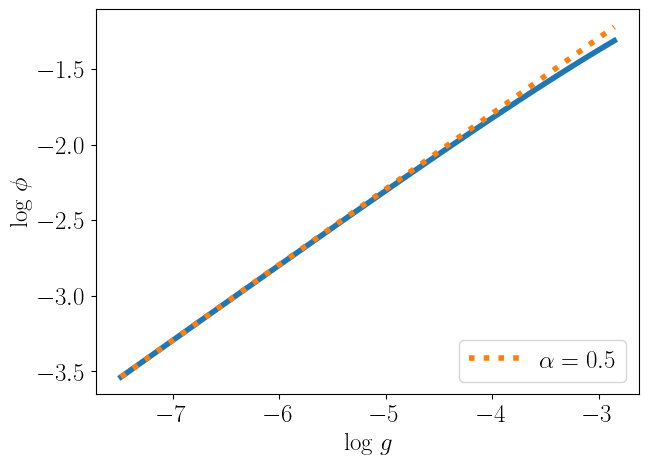

In [44]:
t = 1
delta = 1
Gamma = 1* delta
N_int = 200
bar_n = 1

n_g = 100 

T_LF = (1/(4*delta))*(delta**2 + (Gamma**2 / 4))

g_c = criticalCouplingLM(t, delta, Gamma, distrib = 'Boson')
gs = g_c * np.exp(np.linspace(0, 0.05, num = n_g+1)[1:])
phi_res = []
phi = 0 
for i in range(n_g):
    initial_phi = max(np.abs(phi), 1e0)
    mu, phi = solve_meanFieldEquations(t, gs[i], delta, Gamma, bar_n, initial_mu = 0, initial_phi = initial_phi, distrib = 'cavity', verbose = False)
    phi_res.append(phi)
phi_res = np.array(phi_res, dtype = float)
log_phi = np.log(phi_res)
log_g = np.log(gs - g_c)
fig, ax = plt.subplots(figsize = (7,5))
ax.plot(log_g, log_phi, lw = 4)
ax.plot(log_g, log_phi[0] + 0.5* (log_g - log_g[0]), linestyle = ':', lw = 4, label = r'$\alpha = 0.5$')
ax.legend(loc ='lower right')
ax.set_xlabel(r'log $g$') 
ax.set_ylabel(r'log $\phi$') 


